<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 846 | Val: 205 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-50] Epoch   1/100 | LR: 3.77e-04 | train loss 1.1187 acc 0.491 | val loss 0.8670 acc 0.615 *


[ResNet-50] Epoch   2/100 | LR: 3.77e-04 | train loss 0.8683 acc 0.625 | val loss 0.6660 acc 0.761 *


[ResNet-50] Epoch   3/100 | LR: 3.77e-04 | train loss 0.6267 acc 0.668 | val loss 0.7766 acc 0.629


[ResNet-50] Epoch   4/100 | LR: 3.77e-04 | train loss 0.4940 acc 0.733 | val loss 0.5513 acc 0.810 *


...

[ResNet-50] Epoch  18/100 | LR: 3.77e-05 | train loss 0.1145 acc 0.949 | val loss 0.4727 acc 0.839


[ResNet-50] Epoch  19/100 | LR: 3.77e-05 | train loss 0.0707 acc 0.968 | val loss 0.4395 acc 0.859


[ResNet-50] Epoch  20/100 | LR: 3.77e-05 | train loss 0.0747 acc 0.973 | val loss 0.4346 acc 0.863


[ResNet-50] Epoch  21/100 | LR: 3.77e-05 | train loss 0.0569 acc 0.979 | val loss 0.4308 acc 0.854


[ResNet-50] Epoch  22/100 | LR: 3.77e-05 | train loss 0.0583 acc 0.975 | val loss 0.4399 acc 0.849

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 22.

[ResNet-50] Restored best checkpoint (val loss = 0.3568)


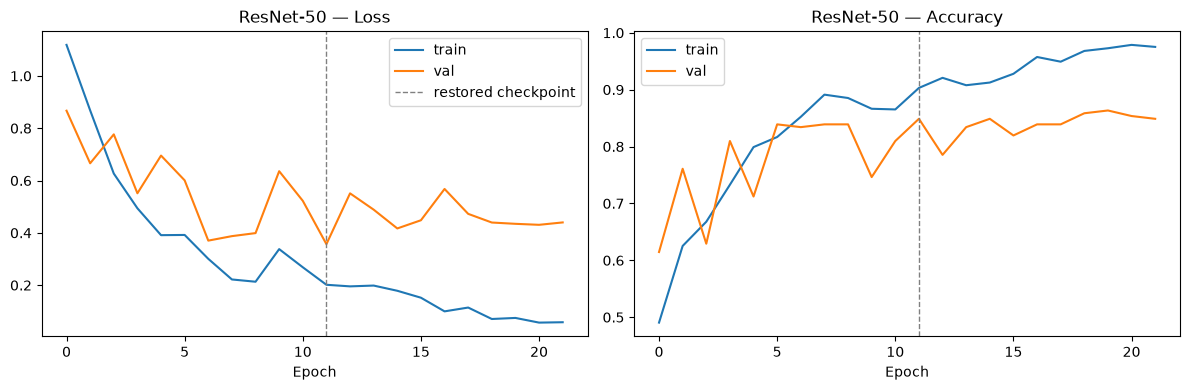

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.669


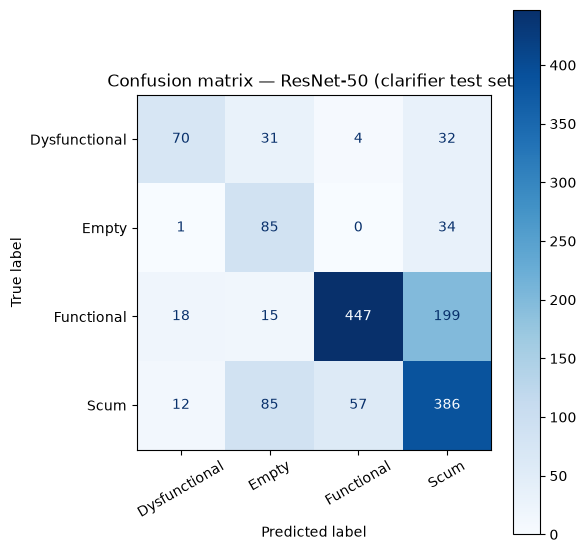

               precision    recall  f1-score   support

Dysfunctional      0.693     0.511     0.588       137
        Empty      0.394     0.708     0.506       120
   Functional      0.880     0.658     0.753       679
         Scum      0.593     0.715     0.648       540

     accuracy                          0.669      1476
    macro avg      0.640     0.648     0.624      1476
 weighted avg      0.718     0.669     0.679      1476



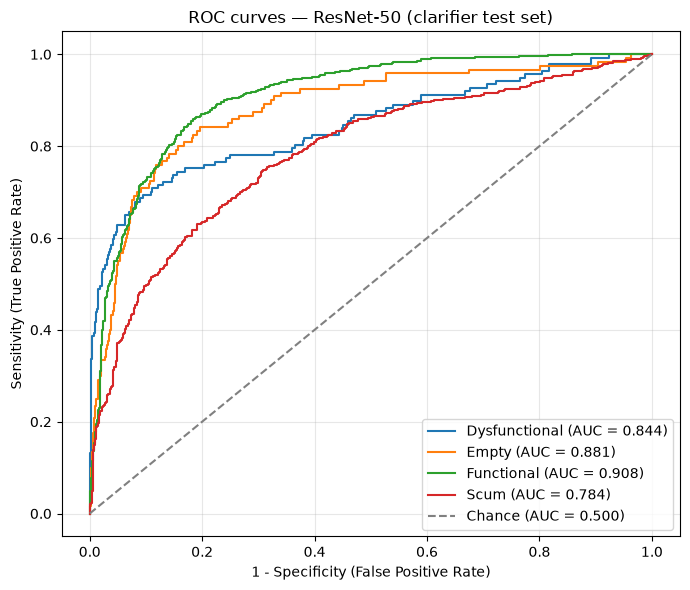

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.844
  Empty          : 0.881
  Functional     : 0.908
  Scum           : 0.784

Mean AUC (over 4/4 classes with test examples): 0.854


(np.float64(0.6693766937669376),
 {'Dysfunctional': 0.8443276658144492,
  'Empty': 0.880653883972468,
  'Functional': 0.9079889053760142,
  'Scum': 0.7835588793922128})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/clarifier_aug/results_clarifier_resnet50_CapeFlats.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
